Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

# Initialization - Rate only

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import pytensor

pd.set_option('display.max_columns', None); pd.set_option('display.width', 1000); pd.set_option('display.max_colwidth', None)
pd.options.mode.string_storage = "python"; pd.options.future.infer_string = False

plot_target = 'word'

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
R, T, F = 8.3145, 293.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)

E_in = np.concatenate([experiments_interp[(C, P)]['E'] for C in C_KOH_list for P in P_CO_list])
C_KOH_in = np.concatenate([np.full_like(experiments_interp[(C, P)]['E'], C) for C in C_KOH_list for P in P_CO_list])
P_CO_in = np.concatenate([np.full_like(experiments_interp[(C, P)]['E'], P) for C in C_KOH_list for P in P_CO_list])
log_rate_obs = np.concatenate([experiments_interp[(C, P)]['log_rate'] for C in C_KOH_list for P in P_CO_list])
log_rate_obs_SD = np.concatenate([experiments_interp[(C, P)]['log_rate_SD'] for C in C_KOH_list for P in P_CO_list])

def add_post_sampling_observables(trace):
    """Calculate rate, alpha, delta_OH and delta_CO after sampling."""
    trace.posterior['rate_linear'] = np.exp(trace.posterior['log_rate_model'])

    # 2. Calculate alpha
    log_rate_samples = trace.posterior['log_rate_model'].values
    alpha_samples = np.zeros_like(log_rate_samples)
    model_log_rates = {}
    start = 0
    for C in C_KOH_list:
        for P in P_CO_list:
            E_arr = experiments_interp[(C, P)]['E']
            end = start + len(E_arr)
            alpha_samples[:, :, start:end] = (R * T / F) * np.gradient(log_rate_samples[:, :, start:end], E_arr[1] - E_arr[0], axis=2)
            model_log_rates[(C, P)] = log_rate_samples[:, :, start:end]
            start = end
    trace.posterior['alpha'] = (trace.posterior['log_rate_model'].dims, alpha_samples)
    
    # 3. Calculate delta_OH
    delta_OH_list = []
    ln_C = np.log(C_KOH_list)
    w_C = ((ln_C - np.mean(ln_C)) / np.sum((ln_C - np.mean(ln_C))**2))[None, None, :, None]
    for P in P_CO_list:
        E_arrays = [np.round(experiments_interp[(C, P)]['E'], 6) for C in C_KOH_list]
        common_E = E_arrays[0]
        for arr in E_arrays[1:]: common_E = np.intersect1d(common_E, arr)   
        rates_for_fit = []
        for C in C_KOH_list:
            E_arr = np.round(experiments_interp[(C, P)]['E'], 6)
            mask = np.isin(E_arr, common_E)
            rates_for_fit.append(model_log_rates[(C, P)][:, :, mask])    
        rates_for_fit = np.stack(rates_for_fit, axis=2)
        delta_OH = np.sum(w_C * rates_for_fit, axis=2)
        delta_OH_list.append(delta_OH)
    trace.posterior['delta_OH_model'] = (("chain", "draw", "delta_OH_flat"), np.concatenate(delta_OH_list, axis=2))
    
    # 4. Calculate delta_CO
    delta_CO_list = []
    for C in C_KOH_list:
        for i in range(len(P_CO_list) - 1):
            P1, P2 = P_CO_list[i], P_CO_list[i+1]
            E1 = np.round(experiments_interp[(C, P1)]['E'], 6)
            E2 = np.round(experiments_interp[(C, P2)]['E'], 6)
            common_E = np.intersect1d(E1, E2)
            mask1 = np.isin(E1, common_E); mask2 = np.isin(E2, common_E)
            lr1 = model_log_rates[(C, P1)][:, :, mask1]
            lr2 = model_log_rates[(C, P2)][:, :, mask2]
            delta_CO = (lr2 - lr1) / np.log(P2 / P1)
            delta_CO_list.append(delta_CO)       
    trace.posterior['delta_CO_model'] = (("chain", "draw", "delta_CO_flat"), np.concatenate(delta_CO_list, axis=2))
    
    return trace

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    chains, draws, N = y_pred.shape
    y_pred_flat = y_pred.reshape(chains * draws, N)
    return az.r2_score(y_true, y_pred_flat)['r2']

In [2]:
def plot_posteriors(trace, model, target='word'): 

    all_vars = list(trace.posterior.data_vars)
    excluded_vars = ['alpha', 'delta_OH_model', 'delta_CO_model', 'rate_linear', 'log_rate', 'log_rate_model']
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta') and v not in excluded_vars]
    summary = az.summary(trace, var_names=kinetic_vars)
    print(summary)
    
    num_vars = len(kinetic_vars)
    cols = min(4, max(1, num_vars)) 
    rows = int(np.ceil(num_vars / cols)) 
    if target == 'ppt':
        rc_update = {'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2}
        figsize_post = (3.0 * cols, 3.5 * rows) 
        title_size = 20; text_size_adj = 12 
    else:
        rc_update = {'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 1.5}
        figsize_post = (2.5 * cols, 3.0 * rows) 
        title_size = 14; text_size_adj = 10

    # Use a context manager so we don't permanently alter or break notebook plotting behavior
    with plt.rc_context(rc_update):
        if kinetic_vars:
            axes = az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, round_to=3, figsize=figsize_post, grid=(rows, cols), textsize=text_size_adj)
            axes_flat = np.array(axes).flatten() 
            for ax in axes_flat: 
                if ax is not None and hasattr(ax, 'texts'):
                    for text_obj in ax.texts: 
                        if 'mean' in text_obj.get_text(): text_obj.set_fontweight('bold')
                    ax.title.set_fontweight('bold')     
            plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.88); plt.show()
        if len(kinetic_vars) > 1:
            az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, figsize=(8,8), textsize=10); plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)
    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
      
    return ppc

def plot_model_fits(trace, ppc, target='word'):

    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize_4x4 = (12, 11); figsize_3x4 = (12, 8.5); figsize_1x4 = (12, 4)   
        title_size, label_size = 18, 14
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize_4x4 = (7.5, 7); figsize_3x4 = (7.5, 5.5); figsize_1x4 = (7.5, 2.5)
        title_size, label_size = 12, 10
    colors = plt.cm.tab10.colors[:len(P_CO_list)]
    
    # 95% CI multiplier for the mean with n=4 replicates (df=3, t=3.182)
    ci_multiplier = 3.182 / np.sqrt(4) 

    def get_model_slice(var_track, C_KOH, P_CO, is_ppc=False):
        dataset = ppc.posterior_predictive if is_ppc else trace.posterior
        if var_track in ['log_rate_model', 'rate_linear', 'alpha'] or is_ppc:
            idx = 0
            for C in C_KOH_list:
                for P in P_CO_list:
                    length = len(experiments_interp[(C, P)]['E'])
                    if C == C_KOH and P == P_CO:
                        return dataset[var_track if not is_ppc else 'rate'][:, :, idx:idx+length], experiments_interp[(C, P)]['E']
                    idx += length
        elif var_track == 'delta_OH_model':
            idx = 0
            for P in P_CO_list:
                E_arrays = [np.round(experiments_interp[(C, P)]['E'], 6) for C in C_KOH_list]
                common_E = E_arrays[0]
                for arr in E_arrays[1:]: common_E = np.intersect1d(common_E, arr)
                length = len(common_E)
                if P == P_CO: return dataset[var_track][:, :, idx:idx+length], common_E
                idx += length
        elif var_track == 'delta_CO_model':
            idx = 0
            for C in C_KOH_list:
                for i in range(len(P_CO_list)-1):
                    P1, P2 = P_CO_list[i], P_CO_list[i+1]
                    E1 = np.round(experiments_interp[(C, P1)]['E'], 6)
                    E2 = np.round(experiments_interp[(C, P2)]['E'], 6)
                    common_E = np.intersect1d(E1, E2)
                    length = len(common_E)
                    if C == C_KOH and P1 == P_CO: return dataset[var_track][:, :, idx:idx+length], common_E
                    idx += length

    def plot_grid(var_fit, var_track, nrows, ncols, figsize, ylabel, title_text, is_3x4=False, is_1x4=False):
        is_ppc = (var_fit in ppc.posterior_predictive.data_vars)
        share_y = False if var_fit == 'rate_linear' else True
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex='col', sharey=share_y)
        fig.suptitle(title_text, fontsize=title_size, fontweight='bold', y=0.96) # Adjusted y down slightly
        fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size + 2)
        fig.supylabel(ylabel, fontweight='bold', fontsize=label_size + 2)

        for i, C_KOH in enumerate(C_KOH_list):
            for j, P_CO in enumerate(P_CO_list):
                if is_1x4 and i > 0: continue
                if is_3x4 and j >= 3: continue

                if is_1x4:
                    ax = axes[j]
                    cond_key = (C_KOH_list[1], P_CO) 
                    exp_mean = experiments_interp[cond_key]['untruncated_delta_OH']
                    exp_sd = experiments_interp[cond_key]['untruncated_delta_OH_SD']
                    E_exp = experiments_interp[cond_key]['untruncated_E_OH']
                    model_slice, E_model = get_model_slice(var_track, None, P_CO, is_ppc)
                elif is_3x4:
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO)
                    exp_mean = experiments_interp[cond_key]['untruncated_delta_CO']
                    exp_sd = experiments_interp[cond_key]['untruncated_delta_CO_SD']
                    E_exp = experiments_interp[cond_key]['untruncated_E_CO']
                    model_slice, E_model = get_model_slice(var_track, C_KOH, P_CO, is_ppc)
                else:
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO)
                    if var_fit == 'alpha':
                        exp_mean = experiments_interp[cond_key]['untruncated_alpha']
                        exp_sd = experiments_interp[cond_key]['untruncated_alpha_SD']
                        E_exp = experiments_interp[cond_key]['untruncated_E']
                    elif var_fit == 'rate': # The actual fitted log_rate (TRUNCATED)
                        exp_mean = experiments_interp[cond_key]['log_rate']
                        exp_sd = experiments_interp[cond_key]['log_rate_SD']
                        E_exp = experiments_interp[cond_key]['E']
                    elif var_fit == 'rate_linear': # UNTRUNCATED
                        exp_mean = experiments_interp[cond_key]['untruncated_rate']
                        exp_sd = experiments_interp[cond_key]['untruncated_rate_SD']
                        E_exp = experiments_interp[cond_key]['untruncated_E']    
                    model_slice, E_model = get_model_slice(var_track, C_KOH, P_CO, is_ppc)

                model_mean = model_slice.mean(dim=("chain", "draw"))
                hdi_95 = az.hdi(model_slice, hdi_prob=0.95)[model_slice.name]
                hdi_90 = az.hdi(model_slice, hdi_prob=0.90)[model_slice.name]

                # 1. Experimental Data Handling
                if var_fit != 'rate': 
                    exp_ci = exp_sd * ci_multiplier
                    ax.fill_between(E_exp, exp_mean - exp_ci, exp_mean + exp_ci, color='gray', alpha=0.3, linewidth=0, zorder=1)
                # Plot the experimental mean line for everything
                ax.plot(E_exp, exp_mean, color='black', lw=2.5, alpha=0.6, zorder=2)

                # 2. Model Data Handling (HDI shading is plotted over the truncated Nernstian bounds)
                ax.fill_between(E_model, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, zorder=3)
                ax.fill_between(E_model, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.30, linewidth=0, zorder=4)
                ax.plot(E_model, model_mean, color=colors[j], lw=3.2, zorder=5)
                if j == 0 and not is_1x4: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
                if is_1x4: ax.set_title(f'{P_CO} atm', fontsize=label_size, fontweight='bold')
                if i == 3 and not is_1x4:
                    label_right = f'{P_CO} atm' if not is_3x4 else f'{P_CO_list[j]} - {P_CO_list[j+1]} atm'
                    ax.text(1.05, 0.5, label_right, transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')

        bottom_adj = 0.08
        if is_1x4: top_adj = 0.80; bottom_adj = 0.2
        elif var_fit == 'rate_linear': top_adj = 0.88
        elif is_3x4: top_adj = 0.88; bottom_adj = 0.10
        else: top_adj = 0.90
        plt.tight_layout(); plt.subplots_adjust(right=0.92, top=top_adj, left=0.10, bottom=bottom_adj); plt.show()

    plot_grid('rate', 'log_rate_model', 4, 4, figsize_4x4, "log Rate", "Log Rate")
    plot_grid('rate_linear', 'rate_linear', 4, 4, figsize_4x4, "Rate", "Rate")
    plot_grid('alpha', 'alpha', 4, 4, figsize_4x4, "alpha", "Transfer Coefficients")
    plot_grid('delta_OH', 'delta_OH_model', 1, 4, figsize_1x4, "Order (OH)", "OH Reaction Order", is_1x4=True)
    plot_grid('delta_CO', 'delta_CO_model', 3, 4, figsize_3x4, "Order (CO)", "CO Reaction Order", is_3x4=True)
    plt.rcParams.update(plt.rcParamsDefault)

def plot_coverages(trace, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize = (12, 11) 
        title_size, label_size = 20, 16
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize = (7.5, 6.5)
        title_size, label_size = 12, 10

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex='col', sharey=True)    
    fig.suptitle('Modeled Surface Coverages', fontsize=title_size, fontweight='bold', y=0.97)
    fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size+2)
    fig.supylabel("Coverage", fontweight='bold', fontsize=label_size+2)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']

            for var, col, lab in zip(['theta_CO', 'theta_OH', 'theta_COOH'], 
                                     ['tab:red', 'tab:blue', 'tab:green'], 
                                     [r'$\theta_{CO}$', r'$\theta_{OH}$', r'$\theta_{COOH}$']):
                if var in trace.posterior:
                    idx = 0
                    for C in C_KOH_list:
                        for P in P_CO_list:
                            length = len(experiments_interp[(C, P)]['E'])
                            if C == C_KOH and P == P_CO:
                                data = trace.posterior[var][:, :, idx:idx+length]
                            idx += length
                            
                    mu = data.mean(dim=("chain", "draw"))
                    hdi = az.hdi(data, hdi_prob=0.95)[var]
                    ax.fill_between(E_exp, hdi[:, 0], hdi[:, 1], color=col, alpha=0.15, linewidth=0)
                    ax.plot(E_exp, mu, color=col, label=lab, lw=2.5)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
            if i == 0 and j == 0: ax.legend(loc='best', frameon=False, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(right=0.92, top=0.90, bottom=0.08, left=0.10) 
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

In [3]:
def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    trace = add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate_model):
    pm.Deterministic('log_rate_model', log_rate_model)
    log_rate = pm.StudentT('rate', nu=3, mu=log_rate_model, sigma=log_rate_obs_SD, observed=log_rate_obs)
    return log_rate

# ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.46,7
,3000,0,0.40,7
,3000,0,0.48,7
,3000,0,0.45,15


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -559.29    39.40
p_loo       25.52        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



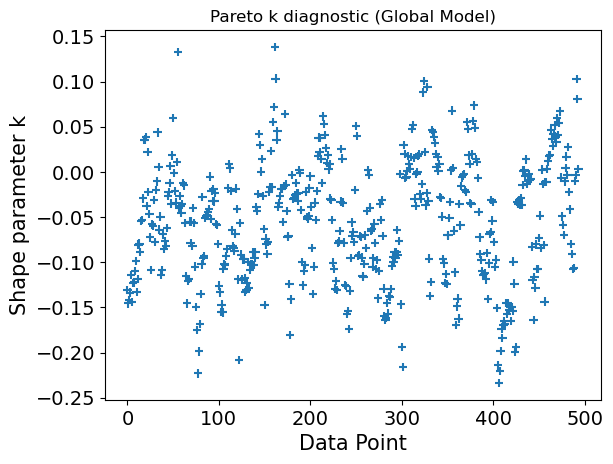

In [4]:
with pm.Model() as ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.25, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=-0.30, sigma=0.25, upper=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=2.5, beta=7.5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.05) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.05) 

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
Gact2_ER_0  0.748  0.001   0.747    0.749        0.0      0.0    1745.0    2291.0    1.0
Gact2_LH_0  0.769  0.006   0.758    0.780        0.0      0.0    1712.0    1850.0    1.0
deltaG1_0  -0.122  0.002  -0.126   -0.118        0.0      0.0    1554.0    1936.0    1.0
deltaG4_0  -0.025  0.009  -0.040   -0.008        0.0      0.0    1478.0    1982.0    1.0
beta_2      0.268  0.007   0.254    0.279        0.0      0.0    1335.0    1530.0    1.0


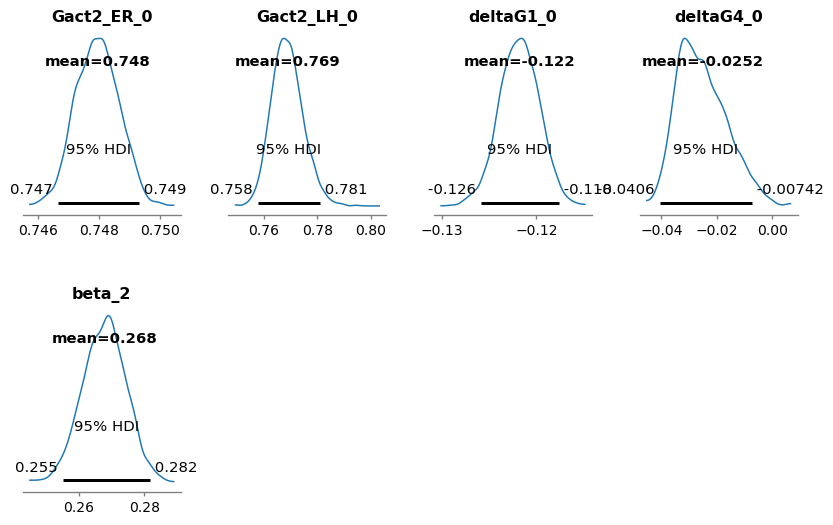

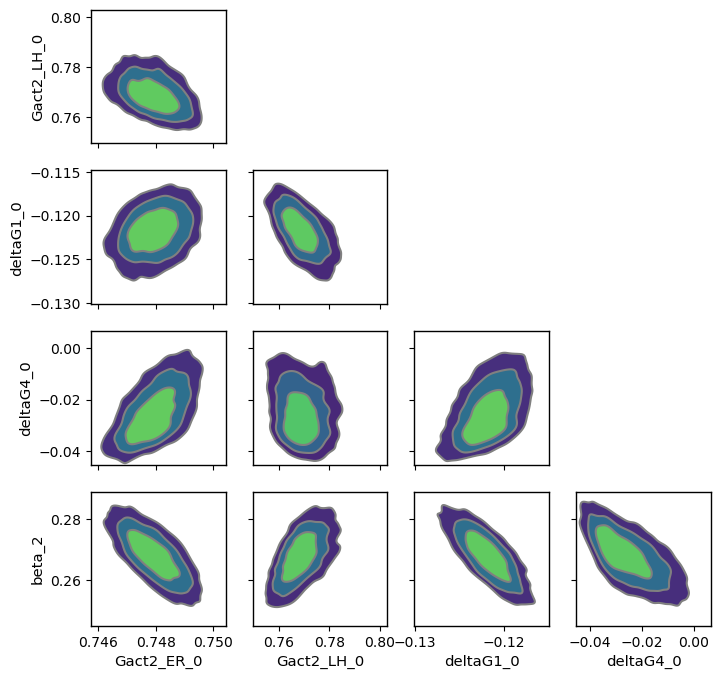

Sampling: [rate]


rate: 0.807


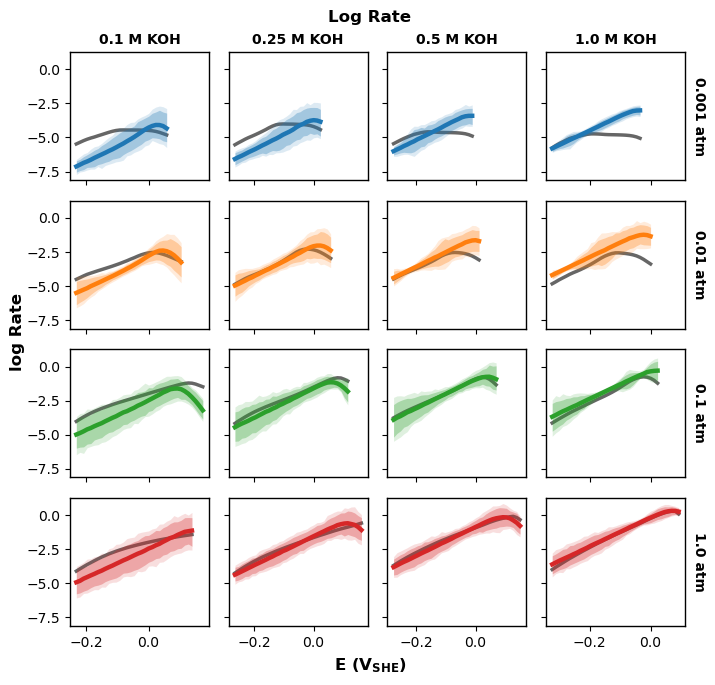

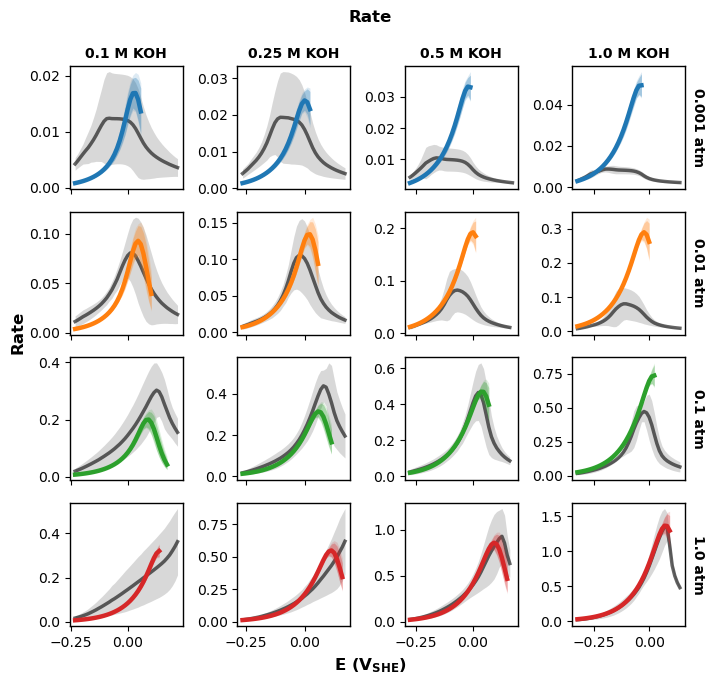

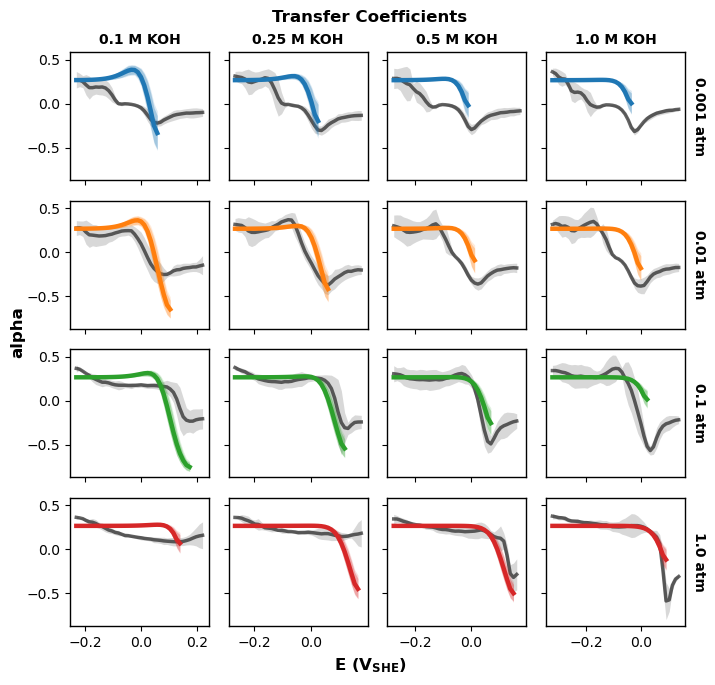

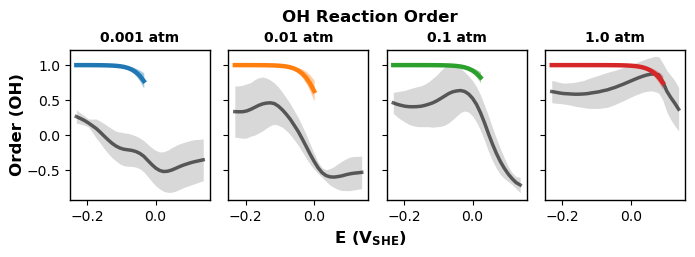

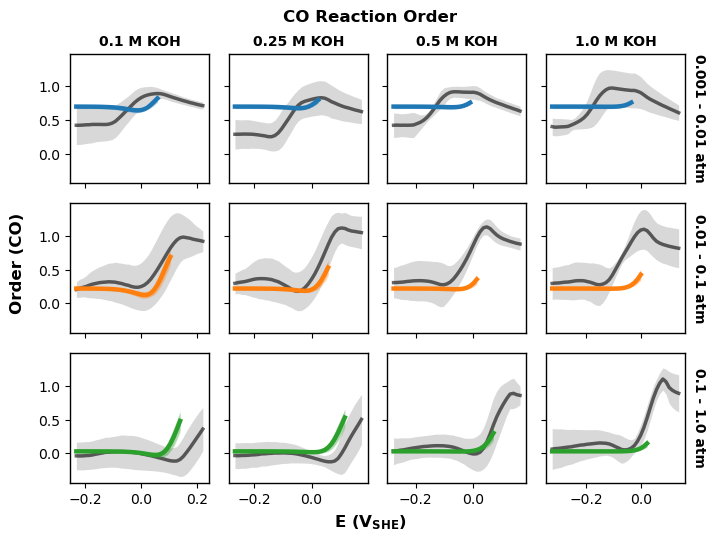

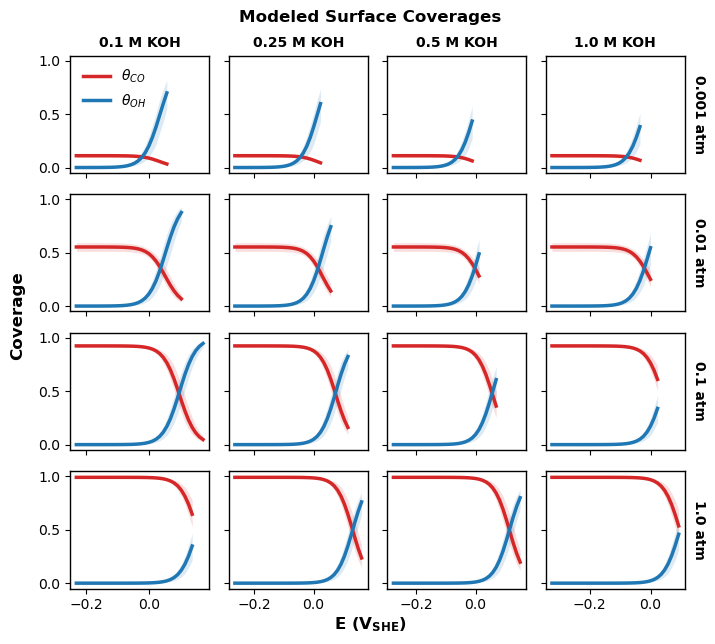

In [5]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2, plot_target)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,31
,3000,0,0.23,31
,3000,0,0.22,7
,3000,0,0.23,63


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -547.05    38.11
p_loo       12.74        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      493   99.8%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


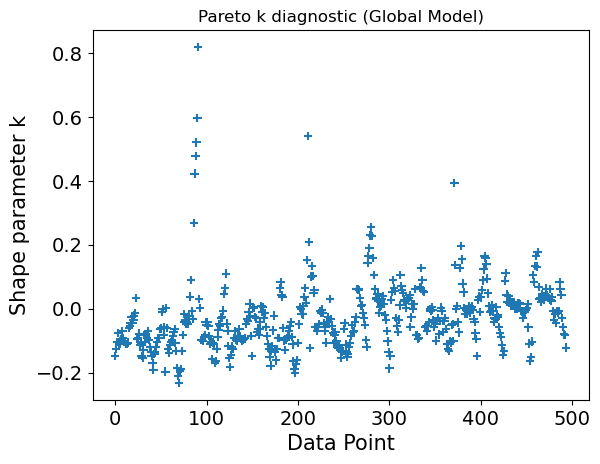

In [6]:
with pm.Model() as ER_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.20, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) 
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.45, sigma=0.05) 
    beta_2 = pm.Beta('beta_2', alpha=10.0, beta=30.0)
    beta_3 = pm.Beta('beta_3', alpha=20.0, beta=20.0)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.05)
    delta_Gact = pm.TruncatedNormal('delta_Gact', mu=-0.10, sigma=0.02, upper=0.0)
    Gact3_0 = pm.Deterministic('Gact3_0', Gact2_0 + delta_Gact)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2_ER + term_CO + np.log(C_KOH_in) - pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3, target_accept=0.95)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.079  0.028   0.037    0.137      0.001    0.001    1359.0     793.0    1.0
deltaG2_ER_0 -0.455  0.043  -0.531   -0.380      0.001    0.001    3044.0    2523.0    1.0
Gact2_0       0.749  0.001   0.747    0.750      0.000    0.000    2376.0    2634.0    1.0
deltaG1_0    -0.113  0.002  -0.118   -0.109      0.000    0.000    1332.0    2171.0    1.0
beta_2        0.222  0.008   0.208    0.236      0.000    0.000    1376.0    1993.0    1.0
beta_3        0.613  0.041   0.538    0.692      0.001    0.001    1276.0    1626.0    1.0
delta_Gact   -0.106  0.012  -0.129   -0.085      0.000    0.000    1201.0    1432.0    1.0
Gact3_0       0.643  0.012   0.620    0.664      0.000    0.000    1209.0    1524.0    1.0


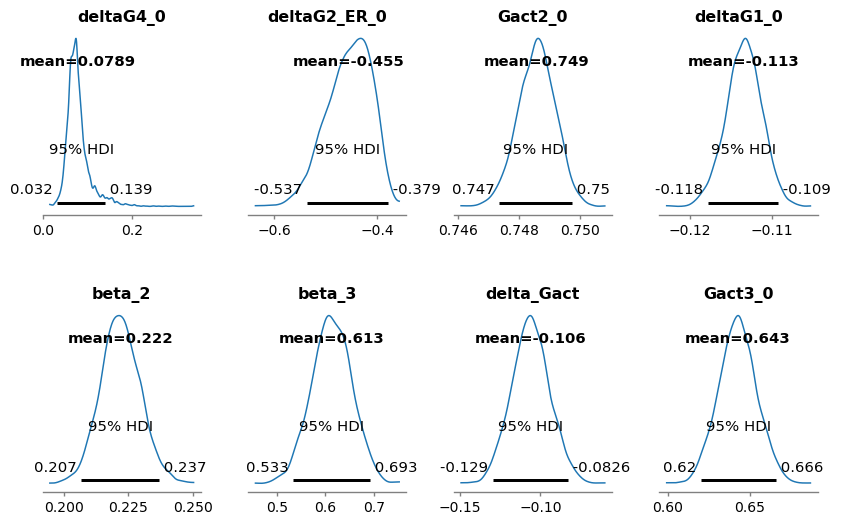

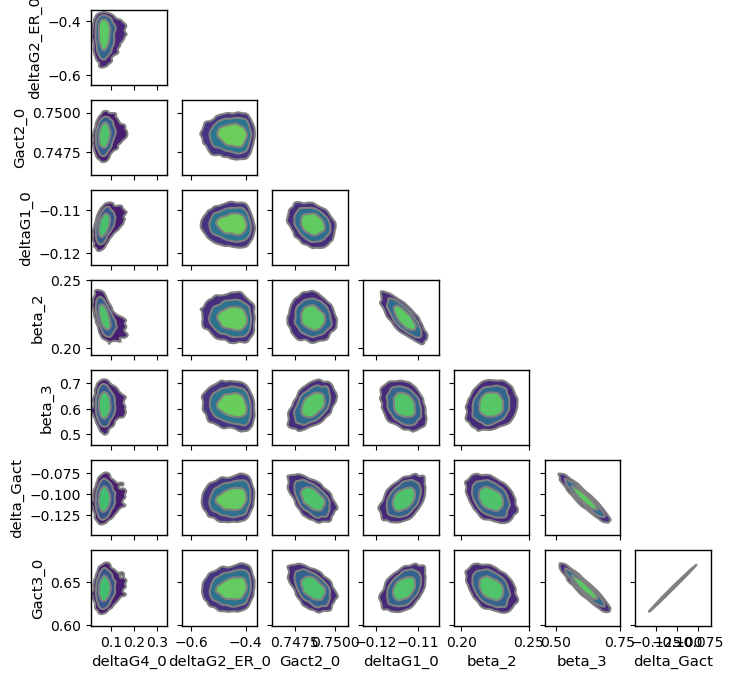

Sampling: [rate]


rate: 0.821


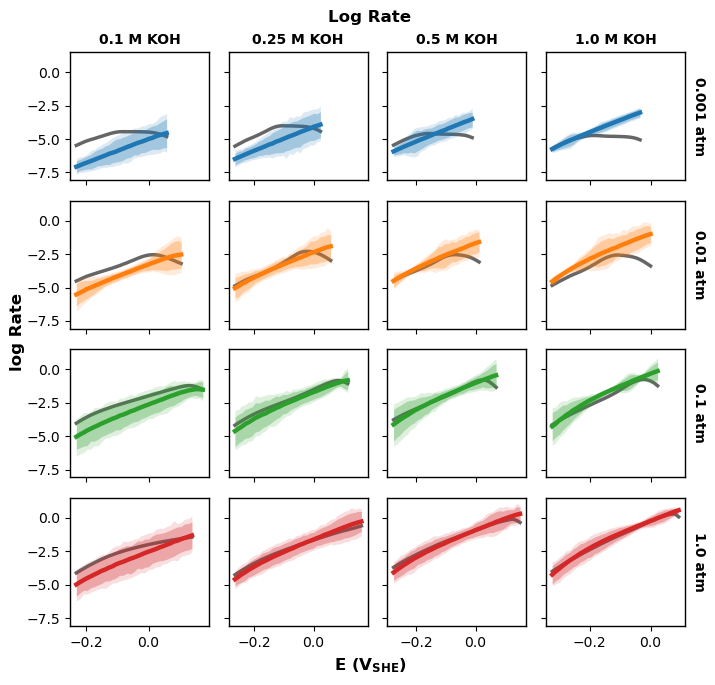

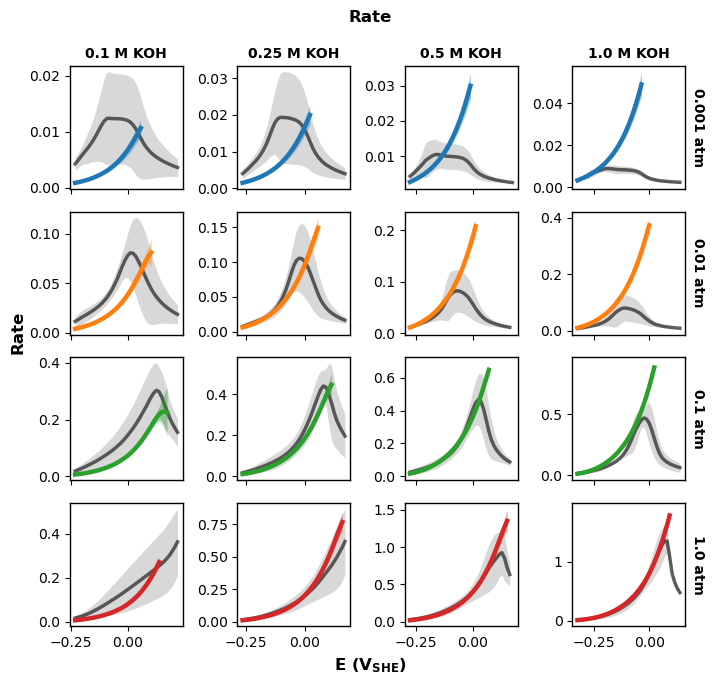

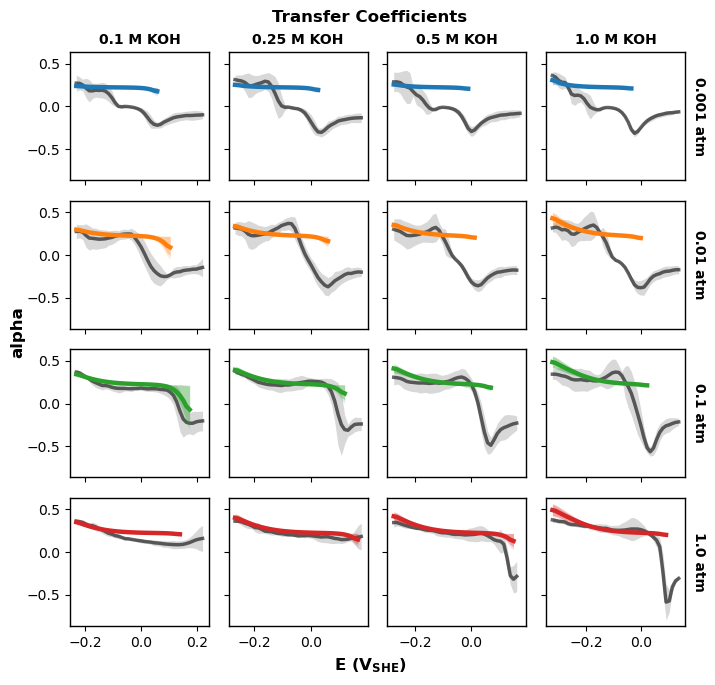

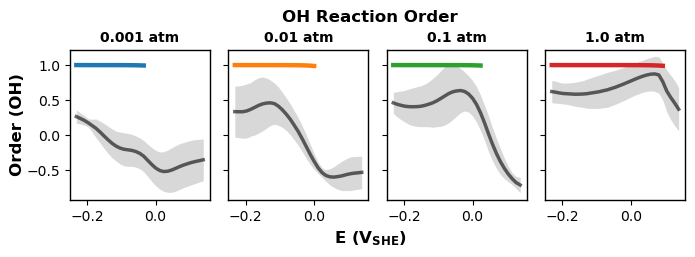

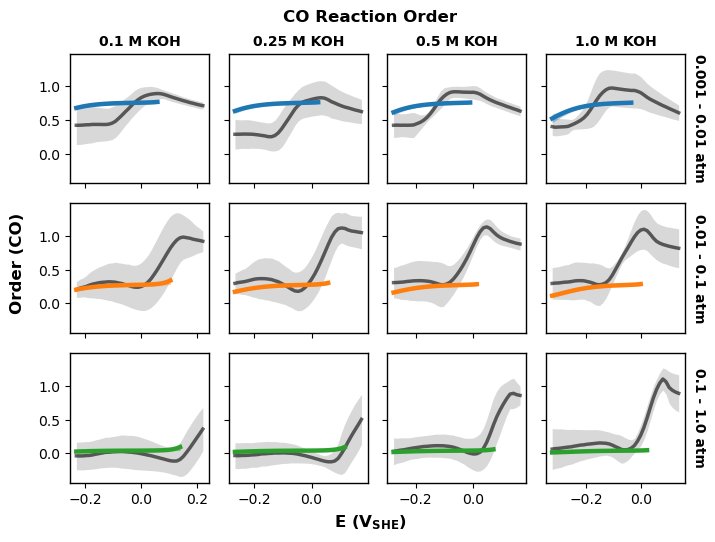

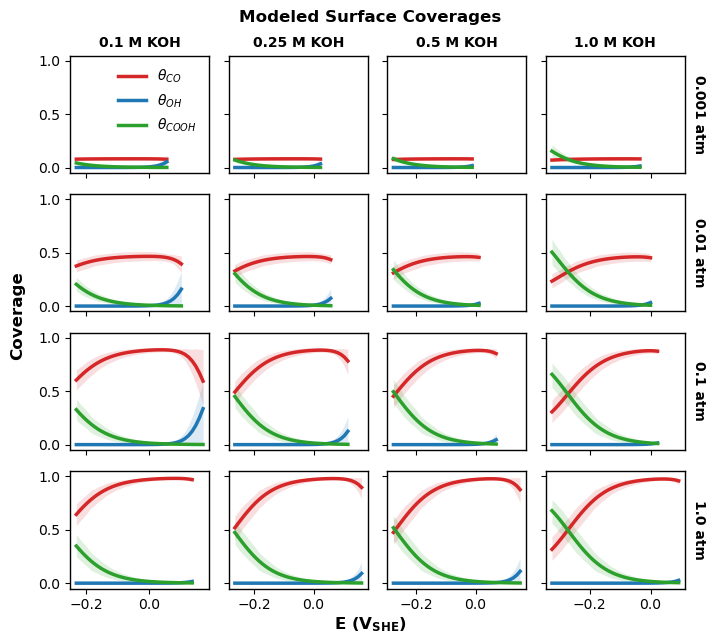

In [7]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3, plot_target)
plot_model_fits(trace_ER_2_3, ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# LH 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,23
,3000,0,0.16,15
,3000,0,0.17,31
,3000,0,0.15,95


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -723.40    44.63
p_loo      252.91        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



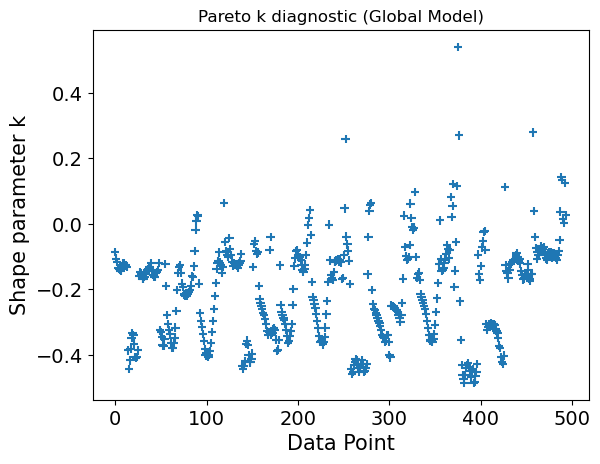

In [8]:
with pm.Model() as LH_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.20, sigma=0.1, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=-0.0, sigma=0.10) 
    deltaG2_LH_0 = pm.Normal('deltaG2_LH_0', mu=-0.35, sigma=0.10) 
    beta_3 = pm.Beta('beta_3', alpha=20.0, beta=20.0)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.05) 
    Gact3_0 = pm.Normal('Gact3_0', mu=0.65, sigma=0.05) 

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_LH_0 
    Gact2 = Gact2_0 
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    # Quadratic solver setup
    log_N_LH = log_k2_LH + term_CO + term_OH
    log_D2 = log_k2_LH - log_K2_LH
    log_S_base = pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    a_quad = pt.exp(log_k3 + np.log(C_KOH_in))
    b_quad = pt.exp(log_D2) + pt.exp(log_k3 + np.log(C_KOH_in) + log_S_base)
    c_quad = -pt.exp(log_N_LH)
    term_COOH = pt.log((-b_quad + pt.sqrt(b_quad**2 - 4*a_quad*c_quad)) / (2*a_quad))

    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_LH_2_3, loo_LH_2_3 = fit_and_evaluate(LH_2_3, target_accept=0.95)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0    -0.315  0.126  -0.418   -0.091      0.062    0.035       8.0      30.0   1.54
deltaG2_LH_0 -0.083  0.233  -0.525    0.098      0.115    0.067       8.0      36.0   1.54
Gact2_0       0.422  0.057   0.372    0.528      0.028    0.016       7.0      33.0   1.53
Gact3_0       0.747  0.001   0.746    0.749      0.000    0.000      14.0      48.0   1.20
deltaG1_0    -0.131  0.075  -0.204   -0.000      0.036    0.020       8.0      34.0   1.54
beta_3        0.272  0.008   0.259    0.289      0.003    0.001       9.0      28.0   1.40


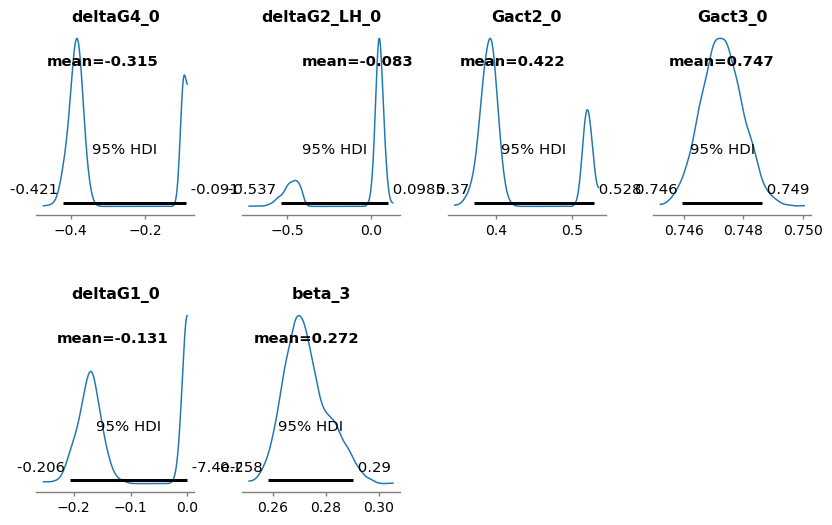

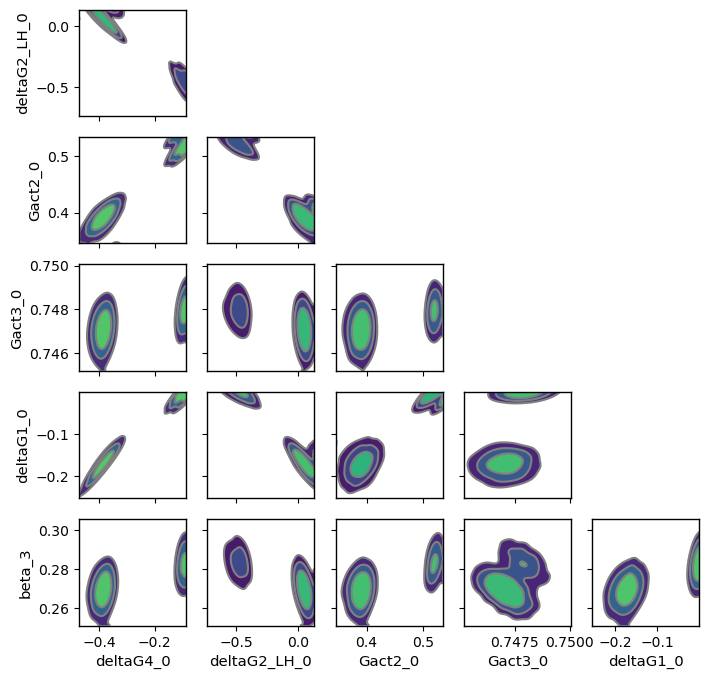

Sampling: [rate]


rate: 0.775


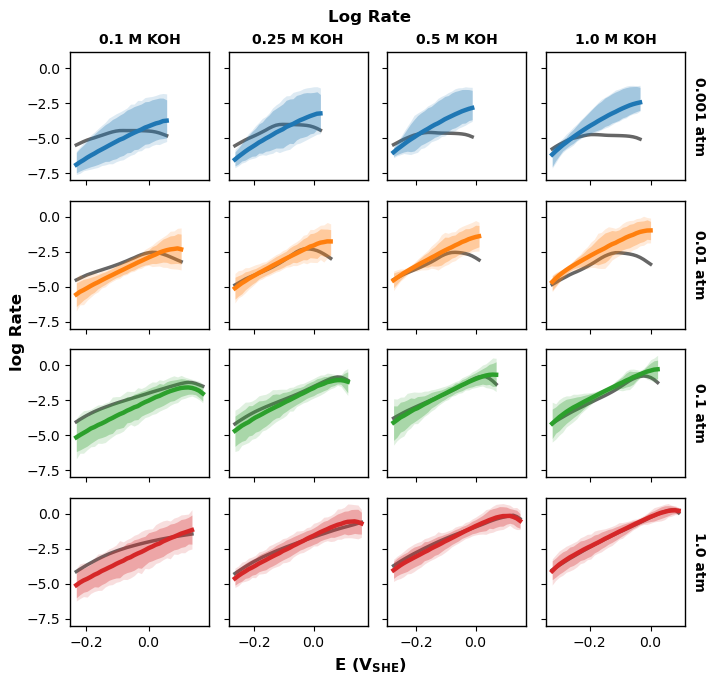

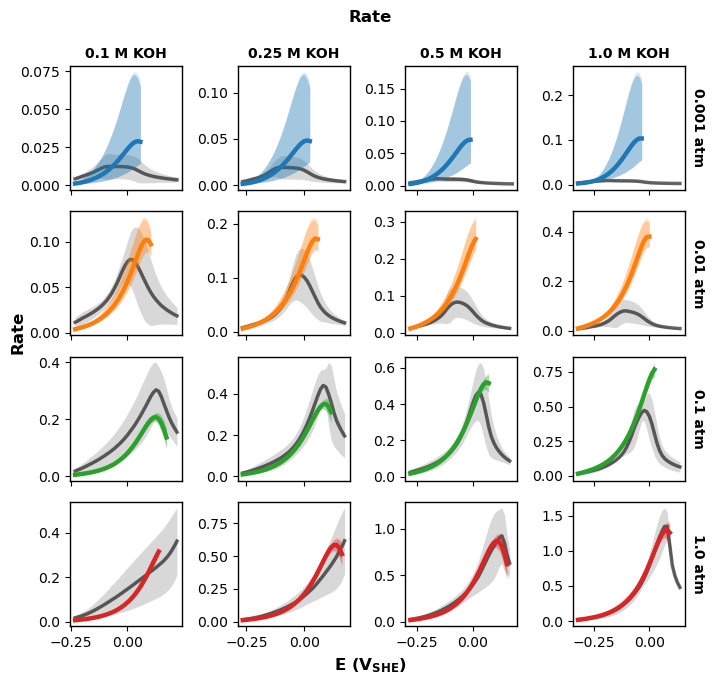

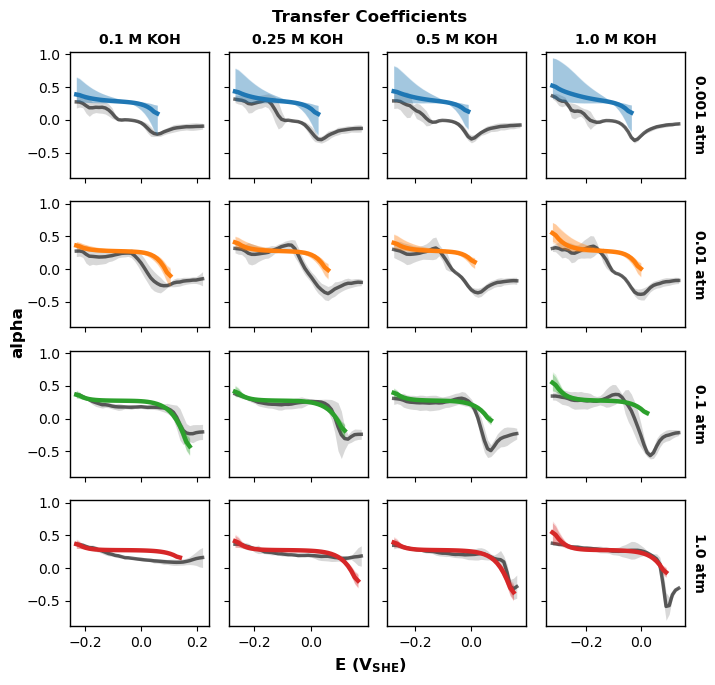

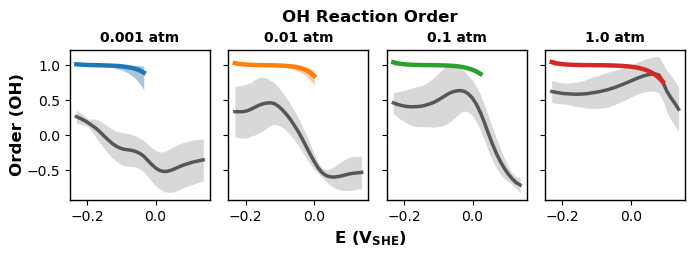

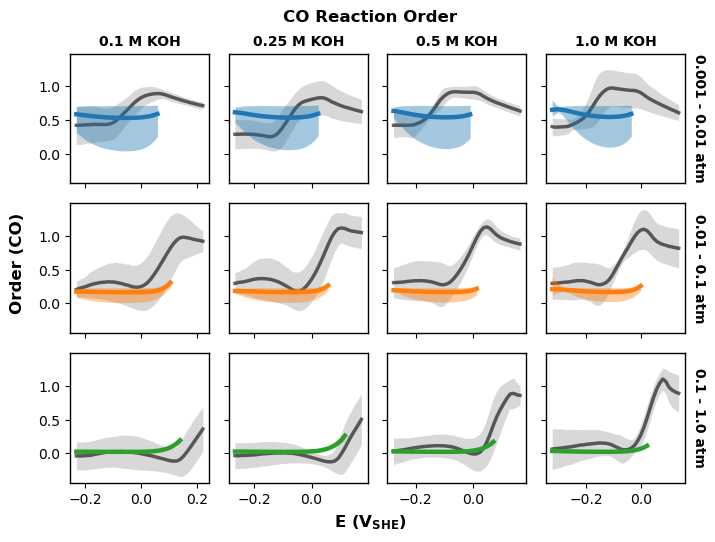

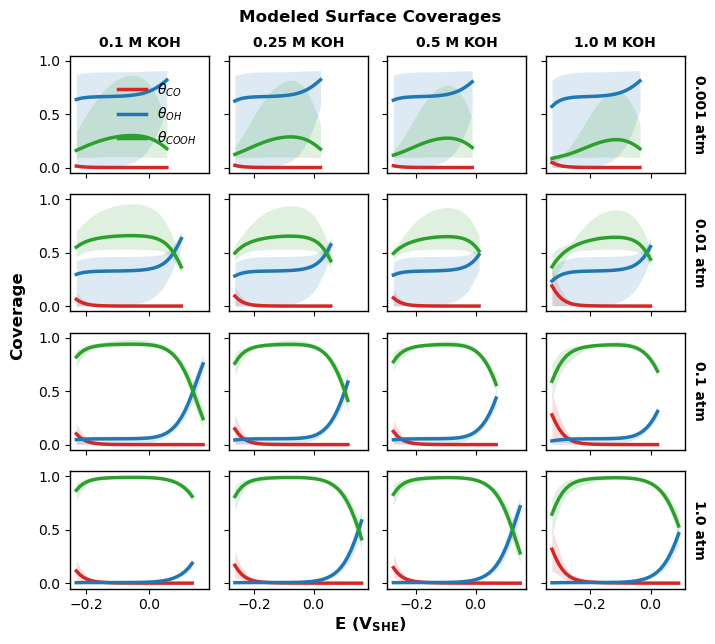

In [9]:
ppc_LH_2_3 = plot_posteriors(trace_LH_2_3, LH_2_3, plot_target)
plot_model_fits(trace_LH_2_3, ppc_LH_2_3); plot_coverages(trace_LH_2_3)

# Comparison

         rank    elpd_loo     p_loo  elpd_diff    weight         se        dse  warning scale
ER_2_3      0 -547.049272  12.73973   0.000000  0.506705  38.105591   0.000000     True   log
ER_LH_2     1 -559.290290  25.51931  12.241018  0.493295  39.404849  16.050372    False   log


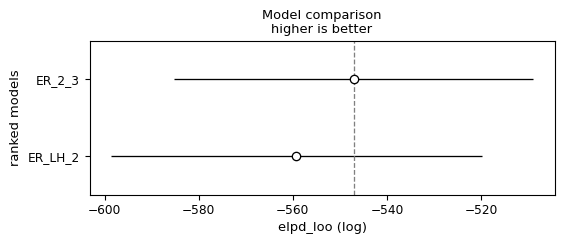

In [11]:
comparison_dict = {
    "ER_LH_2": loo_ER_LH_2,
    "ER_2_3": loo_ER_2_3,
    # "LH_2_3": loo_LH_2_3,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()